In [15]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
from src.processing import process_data

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

train_processed = process_data(train, is_train=True)
test_processed = process_data(test, is_train=False)

target = 'exam_score'
features = [i for i in train_processed.columns if i != target]

for col in features:
    if col not in test_processed.columns:
        test_processed[col] = 0

X = train_processed[features]
y = train_processed[target]
X_test = test_processed[features]

In [16]:
print(train_processed.head())

   age  study_hours  class_attendance  sleep_hours  exam_score  \
0   21         7.91              98.8          4.9        78.3   
1   18         4.95              94.8          4.7        46.7   
2   20         4.68              92.6          5.8        99.0   
3   19         2.00              49.5          8.3        63.9   
4   23         7.65              86.9          9.6       100.0   

   facility_rating_num  exam_difficulty_enc  sleep_quality_val  sleep_index  \
0                    1                    0                  2          9.8   
1                    2                    1                  1          4.7   
2                    3                    1                  1          5.8   
3                    3                    1                  2         16.6   
4                    3                    0                  3         28.8   

   efficiency_index  gender_male  gender_other  internet_access_yes  \
0           7.81508            0             0           

In [17]:
print(test_processed.head())

   age  study_hours  class_attendance  sleep_hours  facility_rating_num  \
0   24         6.85              65.2          5.2                    3   
1   18         6.61              45.0          9.3                    1   
2   24         6.60              98.5          6.2                    2   
3   24         3.03              66.3          5.7                    2   
4   20         2.03              42.4          9.2                    1   

   exam_difficulty_enc  sleep_quality_val  sleep_index  efficiency_index  \
0                    0                  1          5.2           4.46620   
1                    0                  1          9.3           2.97450   
2                    1                  3         18.6           6.50100   
3                    1                  2         11.4           2.00889   
4                    1                  2         18.4           0.86072   

   gender_male  gender_other  internet_access_yes  study_method_group_study  \
0            

In [18]:
print(X.shape)
print(X_test.shape)

(630000, 16)
(270000, 16)


In [21]:
from sklearn.model_selection import train_test_split
X = train_processed.drop(columns=['exam_score'])
y = train_processed['exam_score']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. 初始化模型
# n_estimators: 森林里树的数量，200是一个不错的平衡点
# random_state: 保证你和我跑出来的结果是一样的
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

# 2. 训练模型
print("正在训练随机森林模型...")
rf_model.fit(X_train, y_train)

# 3. 在验证集上做预测（模拟考试）
val_preds = rf_model.predict(X_val)

# 4. 计算分数 (RMSE)
rmse_score = np.sqrt(mean_squared_error(y_val, val_preds))

print("-" * 30)
print(f"✅ 线下验证集 RMSE: {rmse_score:.4f}")
print("-" * 30)

正在训练随机森林模型...
------------------------------
✅ 线下验证集 RMSE: 9.1681
------------------------------


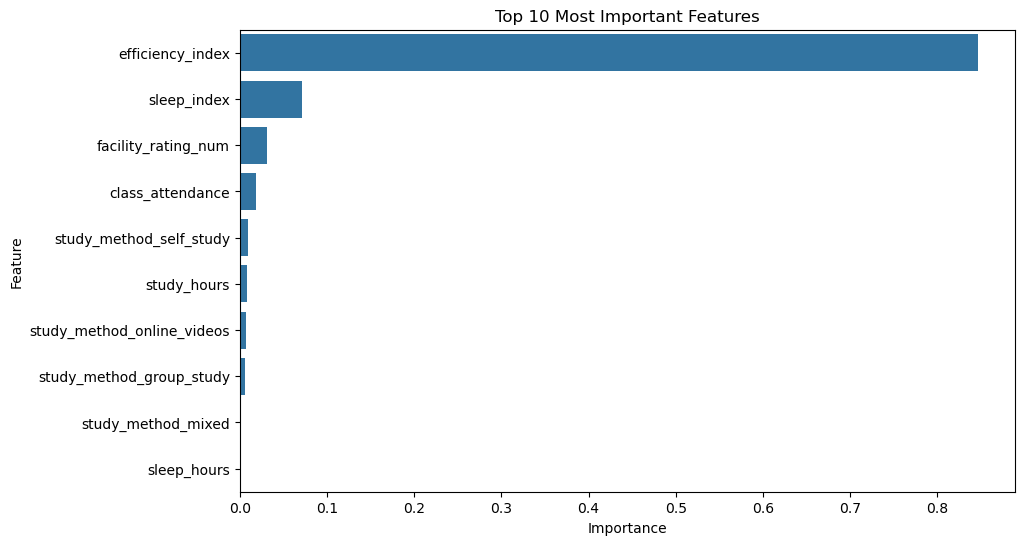

                       Feature  Importance
8             efficiency_index    0.846480
7                  sleep_index    0.070914
4          facility_rating_num    0.031003
2             class_attendance    0.018211
15     study_method_self_study    0.009918
1                  study_hours    0.008794
14  study_method_online_videos    0.007583
12    study_method_group_study    0.005439
13          study_method_mixed    0.000928
3                  sleep_hours    0.000426


In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# 提取特征重要性
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 可视化
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features')
plt.show()

print(feature_importance_df.head(10))

In [26]:
test_preds = rf_model.predict(X_test)

# 2. 加载样例提交文件，确保格式完全一致
submission = pd.read_csv('../data/sample_submission.csv')

# 3. 替换预测值并保存
submission['exam_score'] = test_preds
submission.to_csv('../submissions/RadomForest_v1.csv', index=False)

print("文件已生成：my_first_submission.csv，现在可以去 Kaggle 提交了！")

文件已生成：my_first_submission.csv，现在可以去 Kaggle 提交了！
